## Basic ECOStress soil moisture data manipulation

In [1]:
import rioxarray as rxr
import xarray as xr

In [2]:
# Use GDAL CLI to quickly understand file structure
path = '~/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5'
!gdal raster info {path}

Driver: HDF5/Hierarchical Data Format Release 5
Files: /Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5
Size is 512, 512
Metadata:
  HDFEOS_INFORMATION_HDFEOSVersion=HDFEOS_5.1.16
Subdatasets:
  SUBDATASET_1_NAME=HDF5:"/Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5"://HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/SM
  SUBDATASET_1_DESC=[7142x9030] //HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/SM (32-bit floating-point)
  SUBDATASET_2_NAME=HDF5:"/Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5"://HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/cloud
  SUBDATASET_2_DESC=[7142x9030] //HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/cloud (32-bit floating-point)
  SUBDATASET_3_NAME=HDF5:"/Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5"://HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/water
  SUBDATASET_3_DESC=[7142x9030] //HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/water (32-bit float

In [3]:
!gdal raster info HDF5:"/Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5"://HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/SM

Driver: HDF5Image/HDF5 Dataset
Files: /Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5
Size is 9030, 7142
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]]

In [4]:
# H5netcdf+path -> doesn't get coordinates b/c not cf-compliant
driver = "HDF5"
path = "/Users/scotthenderson/Downloads/ECOv002_L3G_SM_27245_002_20230426T164239_0712_01.h5"
subdataset = "//HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/SM"

# Explore entire hierarchy with DataTree
ds = xr.open_datatree(path,
                     engine='h5netcdf',
                     #phony_dims='sort'
)
ds

/var/folders/1v/k85p3x5d10zb9mhqx88lb3240000gn/T/ipykernel_53439/923637000.py:7: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  ds = xr.open_datatree(path,


<xarray.DataTree>
Group: /
├── Group: /HDFEOS
│   ├── Group: /HDFEOS/ADDITIONAL
│   │   └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
│   │       ├── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES/ProductMetadata
│   │       │       Dimensions:                   (phony_dim_0: 6, phony_dim_1: 1)
│   │       │       Dimensions without coordinates: phony_dim_0, phony_dim_1
│   │       │       Data variables:
│   │       │           AncillaryNWP              <U599 2kB ...
│   │       │           BandSpecification         (phony_dim_0) float32 24B ...
│   │       │           NWPSource                 object 8B ...
│   │       │           NumberOfBands             (phony_dim_1) uint8 1B ...
│   │       │           OrbitCorrectionPerformed  object 8B ...
│   │       │           QAPercentCloudCover       (phony_dim_1) int32 4B ...
│   │       │           QAPercentGoodQuality      (phony_dim_1) int32 4B ...
│   │       └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES/StandardMetadata
│   │               Dimensions:                     (phony_dim_2: 1)
│   │               Dimensions without coordinates: phony_dim_2
│   │               Data variables: (12/46)
│   │                   AncillaryInputPointer       object 8B ...
│   │                   AutomaticQualityFlag        object 8B ...
│   │                   BuildID                     object 8B ...
│   │                   CRS                         <U45 180B ...
│   │                   CampaignShortName           object 8B ...
│   │                   CollectionLabel             object 8B ...
│   │                   ...                          ...
│   │                   SceneID                     object 8B ...
│   │                   ShortName                   <U10 40B ...
│   │                   SouthBoundingCoordinate     (phony_dim_2) float64 8B ...
│   │                   StartOrbitNumber            object 8B ...
│   │                   StopOrbitNumber             object 8B ...
│   │                   WestBoundingCoordinate      (phony_dim_2) float64 8B ...
│   └── Group: /HDFEOS/GRIDS
│       └── Group: /HDFEOS/GRIDS/ECO_L3G_SM_70m
│           └── Group: /HDFEOS/GRIDS/ECO_L3G_SM_70m/Data Fields
│                   Dimensions:  (phony_dim_3: 7142, phony_dim_4: 9030)
│                   Dimensions without coordinates: phony_dim_3, phony_dim_4
│                   Data variables:
│                       SM       (phony_dim_3, phony_dim_4) float32 258MB ...
│                       cloud    (phony_dim_3, phony_dim_4) float32 258MB ...
│                       water    (phony_dim_3, phony_dim_4) float32 258MB ...
└── Group: /HDFEOS INFORMATION
        Dimensions:           ()
        Data variables:
            StructMetadata.0  |S32000 32kB ...
        Attributes:
            HDFEOSVersion:  HDFEOS_5.1.16

In [5]:
# GDAL NetCDF+Path -> No coordinates  but all arrays


ds = xr.open_dataset(f'NETCDF:"{path}"',
                     engine='rasterio',
)
ds


/Users/scotthenderson/GitHub/cresst/gaia-data-downloaders/.pixi/envs/default/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/Users/scotthenderson/GitHub/cresst/gaia-data-downloaders/.pixi/envs/default/lib/python3.13/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/Users/scotthenderson/GitHub/cresst/gaia-data-downloaders/.pixi/envs/default/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/Users/scotthenderson/GitHub/cresst/gaia-data-downloa

<xarray.Dataset> Size: 774MB
Dimensions:      (band: 1, x: 9030, y: 7142)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 72kB 0.5 1.5 2.5 ... 9.028e+03 9.028e+03 9.03e+03
  * y            (y) float64 57kB 0.5 1.5 2.5 ... 7.14e+03 7.14e+03 7.142e+03
    spatial_ref  int64 8B ...
Data variables:
    SM           (band, y, x) float32 258MB ...
    cloud        (band, y, x) float32 258MB ...
    water        (band, y, x) float32 258MB ...
Attributes:
    HDFEOSVersion:  HDFEOS_5.1.16

## Best data loading approach

Use rasterio engine and GDAL-style paths to specific subdatasets

In [6]:
# Automatically load coordinates of subdataset via GDAL

da = xr.open_dataarray(f'{driver}:"{path}":{subdataset}',
                     engine='rasterio',
                     ).squeeze()
da

<xarray.DataArray 'band_data' (y: 7142, x: 9030)> Size: 258MB
[64492260 values with dtype=float32]
Coordinates:
  * y            (y) float64 57kB 50.07 50.07 50.06 50.06 ... 45.07 45.07 45.07
  * x            (x) float64 72kB -123.9 -123.9 -123.9 ... -117.6 -117.6 -117.6
    band         int64 8B 1
    spatial_ref  int64 8B ...
Attributes:
    HDFEOS_INFORMATION_HDFEOSVersion:  HDFEOS_5.1.16

In [7]:
#da.plot.imshow()

# Load cloud mask... I think 1=Cloud
cloud_mask = xr.open_dataarray(f'{driver}:"{path}"://HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/cloud',
                     engine='rasterio',
                     ).squeeze()

# 1 = water, seems to be just inland lakes...
water_mask = xr.open_dataarray(f'{driver}:"{path}"://HDFEOS/GRIDS/ECO_L3G_SM_70m/Data_Fields/water',
                     engine='rasterio',
                     ).squeeze()
water_mask

<xarray.DataArray 'band_data' (y: 7142, x: 9030)> Size: 258MB
[64492260 values with dtype=float32]
Coordinates:
  * y            (y) float64 57kB 50.07 50.07 50.06 50.06 ... 45.07 45.07 45.07
  * x            (x) float64 72kB -123.9 -123.9 -123.9 ... -117.6 -117.6 -117.6
    band         int64 8B 1
    spatial_ref  int64 8B ...
Attributes:
    HDFEOS_INFORMATION_HDFEOSVersion:  HDFEOS_5.1.16

In [8]:
#cloud_mask.plot.imshow()

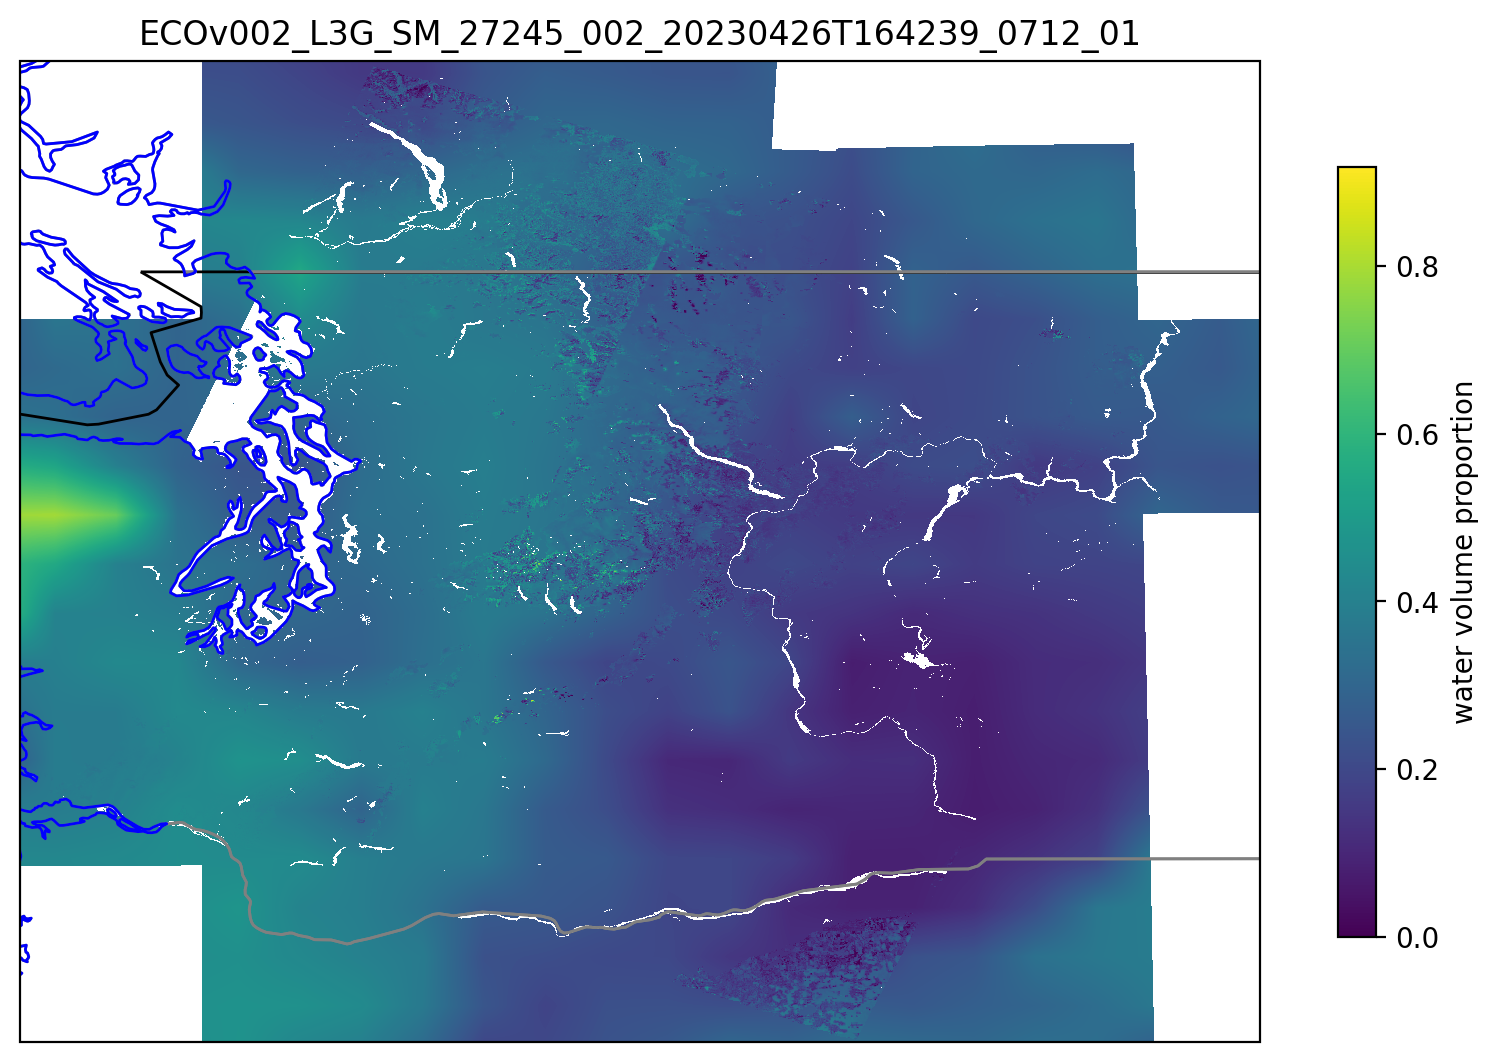

In [9]:
# Use cartopy to ensure we;re properly aligned
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
%config InlineBackend.figure_format = 'retina'

filename = Path(path).stem

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'label': 'water volume proportion', 'shrink': 0.5})
plt.title(filename)
# Add coastline, national boundary, and state boundary layers
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, edgecolor='blue');
